# 3. MINI-LABS (HIỂU TỪNG MODULE QUA VÍ DỤ NHỎ)

## 3.1 FPN – Feature Pyramid Network (trực quan hoá multi-scale)

Using device: cuda
Image: image copy 2.png


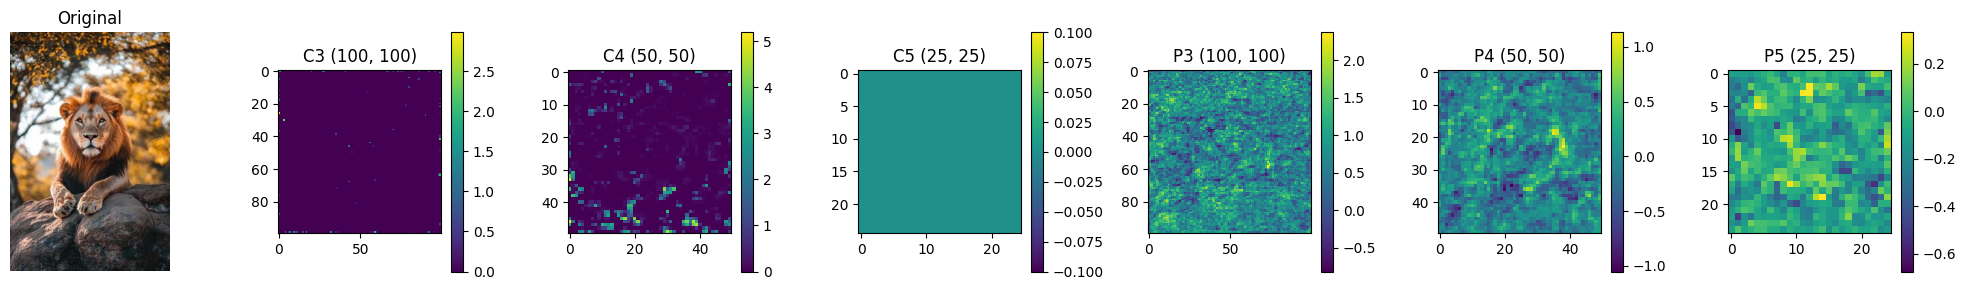

Image: image copy 3.png


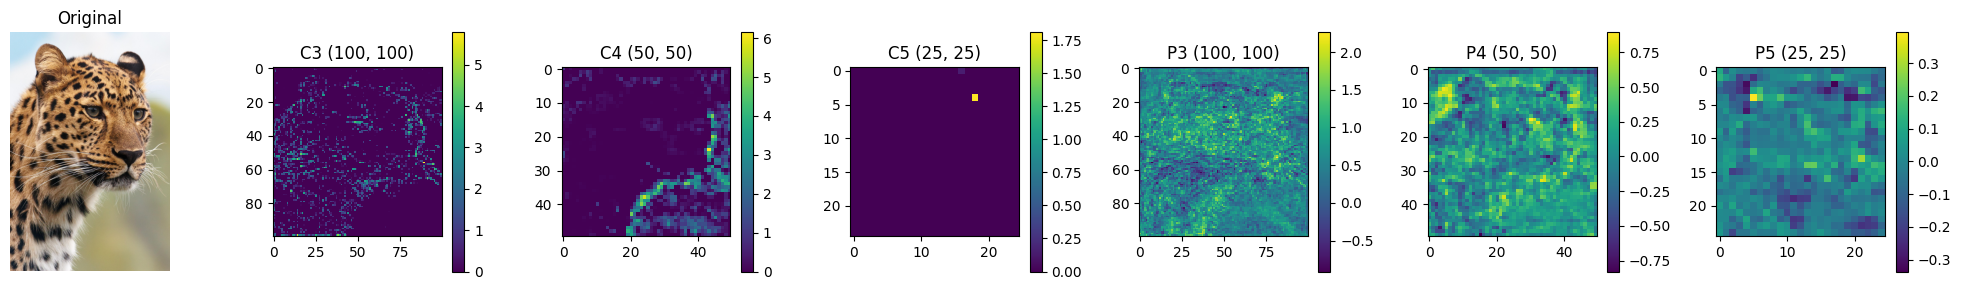

Image: image copy.png


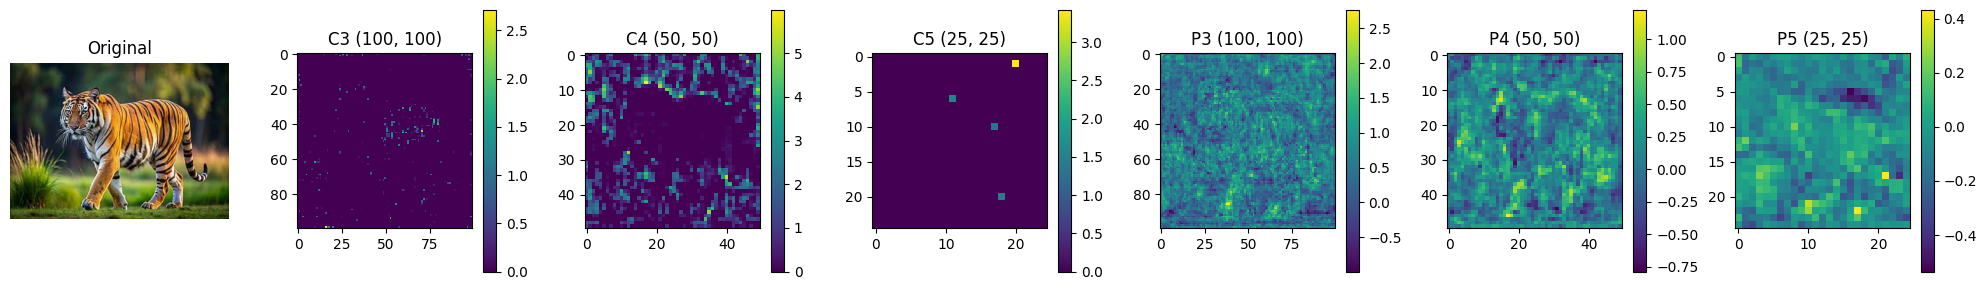

Image: image.png


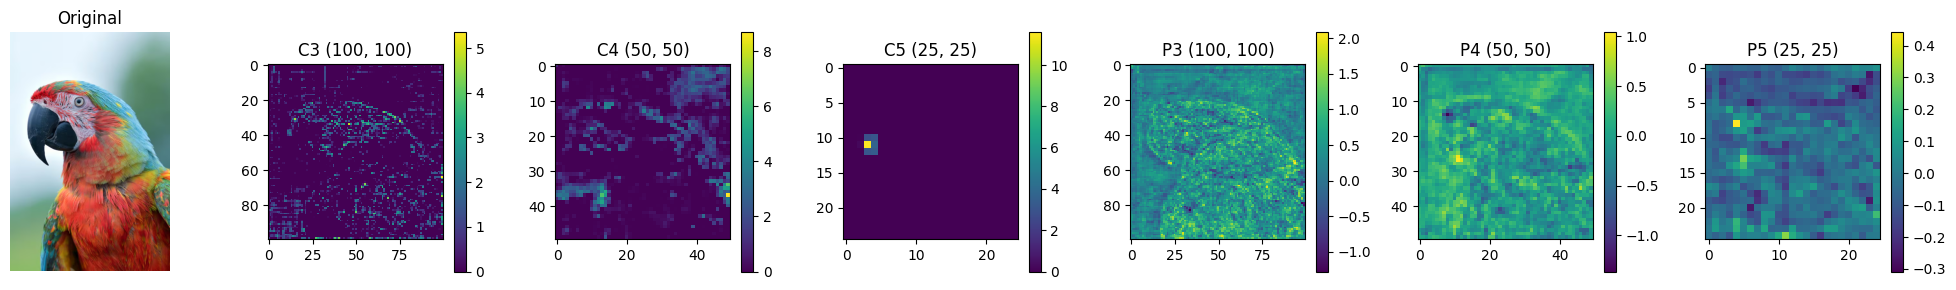

In [2]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision.models.feature_extraction import create_feature_extractor
from PIL import Image
import matplotlib.pyplot as plt

# ----- 1) Define Minimal FPN -----
class SimpleFPN(nn.Module):
    def __init__(self, c3_channels=512, c4_channels=1024, c5_channels=2048, out_channels=256, use_smooth=True):
        super().__init__()
        self.lateral_c3 = nn.Conv2d(c3_channels, out_channels, kernel_size=1)
        self.lateral_c4 = nn.Conv2d(c4_channels, out_channels, kernel_size=1)
        self.lateral_c5 = nn.Conv2d(c5_channels, out_channels, kernel_size=1)

        self.use_smooth = use_smooth
        if use_smooth:
            self.smooth_p5 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            self.smooth_p4 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            self.smooth_p3 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, C3, C4, C5):
        L5 = self.lateral_c5(C5)
        L4 = self.lateral_c4(C4)
        L3 = self.lateral_c3(C3)

        P5 = L5
        P4 = L4 + F.interpolate(P5, size=L4.shape[-2:], mode='nearest')
        P3 = L3 + F.interpolate(P4, size=L3.shape[-2:], mode='nearest')

        if self.use_smooth:
            P5 = self.smooth_p5(P5)
            P4 = self.smooth_p4(P4)
            P3 = self.smooth_p3(P3)

        return P5, P4, P3

# ----- 2) Model & Device Setup -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

backbone = torchvision.models.resnet50(weights="IMAGENET1K_V2").to(device).eval()
nodes = {"layer2": "C3", "layer3": "C4", "layer4": "C5"}
extractor = create_feature_extractor(backbone, return_nodes=nodes)
fpn = SimpleFPN().to(device).eval()

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize((800, 800)),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ----- 3) Helper Heatmap Plotting Function -----
def show_heatmap(feat, title):
    fmap = feat[0, 0].detach().cpu().numpy()
    plt.imshow(fmap, interpolation='nearest')
    plt.title(title)
    plt.colorbar()

# ----- 4) Run on Images in the images directory -----
image_dir = "/content/images"
if os.path.exists(image_dir):
    img_names = [f for f in os.listdir(image_dir) if f.lower().endswith( loam_ext := (".png", ".jpg", ".jpeg") )]

    for name in sorted(img_names):
        img_path = os.path.join(image_dir, name)
        print(f"Image: {name}")

        img = Image.open(img_path).convert("RGB")
        x = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            feats = extractor(x)
            C3, C4, C5 = feats["C3"], feats["C4"], feats["C5"]
            P5, P4, P3 = fpn(C3, C4, C5)

        plt.figure(figsize=(20, 3))

        plt.subplot(1, 7, 1)
        plt.imshow(img)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 7, 2)
        show_heatmap(C3, f"C3 {tuple(C3.shape[-2:])}")

        plt.subplot(1, 7, 3)
        show_heatmap(C4, f"C4 {tuple(C4.shape[-2:])}")

        plt.subplot(1, 7, 4)
        show_heatmap(C5, f"C5 {tuple(C5.shape[-2:])}")

        plt.subplot(1, 7, 5)
        show_heatmap(P3, f"P3 {tuple(P3.shape[-2:])}")

        plt.subplot(1, 7, 6)
        show_heatmap(P4, f"P4 {tuple(P4.shape[-2:])}")

        plt.subplot(1, 7, 7)
        show_heatmap(P5, f"P5 {tuple(P5.shape[-2:])}")

        plt.tight_layout()
        plt.show()
else:
    print(f"Directory {image_dir} does not exist!")

**Nhận xét**

Ảnh đầu vào được resize về (800, 800) rồi thực hiện đưa vào mô hình ResNet để lấy 3 mức đặc trưng C1, C2, C3.

Ở đây C 1, 2, 3 tương ứng với các đặc trưng lấy trực tiếp từ backbone ResNet, Các P 1, 2, 3 là đặc trưng đầu ra của FPN, tức là các feature map sau khi được trích xuất từ ảnh, tiếp tục đi qua khối FPN lấy được đặc trưng của các tầng sâu hơn => Giàu thông tin hơn. Ở đây tầng FPN chỉ thực hiện minh họa, chưa thông qua huấn luyện nên Heatmap còn nhiễu tương đối nhiều.



## 3.2 Anchors & RPN – sinh anchor, chấm điểm, lọc top-k